# 10.3 — Cópulas y correlación de default

Cierra M10. Las curvas de hazard marginales (10.2) no determinan por sí solas la
distribución CONJUNTA de defaults de varios nombres — se necesita una **cópula** para
acoplarlos. La **cópula gaussiana** (Li, 2000) es el estándar de facto (pre y post-2008):
transforma cada tiempo de default marginal a una uniforme vía su propia supervivencia, y
acopla esas uniformes con un vector gaussiano correlacionado.

## 0. Configuración

5 nombres de crédito con curvas de hazard marginales distintas (intensidad constante por
nombre — simplificación pedagógica; en producción cada nombre tendría su propio bootstrap
de 10.2).

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

n_names = 5
lambdas = np.array([0.010, 0.015, 0.020, 0.030, 0.050])  # hazard constante por nombre


def survival_i(t, i):
    return np.exp(-lambdas[i] * t)

## 1. Simulación de la cópula gaussiana

$Z\sim N(0,\Sigma)$ (correlación $\rho$ constante entre pares), $U_i=\Phi(Z_i)$,
$\tau_i=-\ln(U_i)/\lambda_i$ (inversión de la supervivencia exponencial marginal, dado
$U_i$). Esto acopla los $\tau_i$ vía $\rho$ sin distorsionar sus distribuciones
marginales — cada $\tau_i$, mirado por separado, sigue siendo exactamente
$\text{Exp}(\lambda_i)$.

In [2]:
def simulate_default_times(rho, n_paths, rng):
    Sigma = np.full((n_names, n_names), rho)
    np.fill_diagonal(Sigma, 1.0)
    chol = np.linalg.cholesky(Sigma)
    Z = rng.standard_normal((n_paths, n_names)) @ chol.T
    U = norm.cdf(Z)
    return -np.log(U) / lambdas[None, :]


n_paths = 200_000
tau = simulate_default_times(0.3, n_paths, rng)

### Demo 1 — las marginales no se distorsionan por la cópula

Acoplar los tiempos de default con una correlación $\rho$ NO debería cambiar la probabilidad de supervivencia de cada nombre por separado — la cópula solo controla cómo se mueven JUNTOS, no sus distribuciones individuales. Verificamos, para cada uno de los 5 nombres, que la fracción simulada de trayectorias con $\tau_i>t$ sigue coincidiendo con la exponencial exacta de ese nombre.

In [3]:
t_check = 5.0
marginal_checks = []
for i in range(n_names):
    surv_sim = np.mean(tau[:, i] > t_check)
    surv_exact = survival_i(t_check, i)
    se = np.sqrt(surv_exact * (1 - surv_exact) / n_paths)
    z = (surv_sim - surv_exact) / se
    marginal_checks.append(z)
    print(f"nombre {i} (lambda={lambdas[i]}): P(tau>{t_check}) sim={surv_sim:.4f} "
          f"exacta={surv_exact:.4f} z={z:.2f}")

nombre 0 (lambda=0.01): P(tau>5.0) sim=0.9516 exacta=0.9512 z=0.79
nombre 1 (lambda=0.015): P(tau>5.0) sim=0.9274 exacta=0.9277 z=-0.62
nombre 2 (lambda=0.02): P(tau>5.0) sim=0.9045 exacta=0.9048 z=-0.51
nombre 3 (lambda=0.03): P(tau>5.0) sim=0.8603 exacta=0.8607 z=-0.55
nombre 4 (lambda=0.05): P(tau>5.0) sim=0.7792 exacta=0.7788 z=0.40


### Demo 2 — distribución del número de defaults en la cesta

Contamos, en cada trayectoria simulada, cuántos de los 5 nombres defaultearon antes de un horizonte fijo, y repetimos para tres valores de $\rho$. Con $\rho=0$ los defaults son independientes (la distribución del conteo se parece a una binomial, concentrada en el centro); con $\rho$ alto, los nombres tienden a defaultear todos juntos o ninguno — la masa se desplaza hacia los extremos (0 defaults o los 5) y se vacía el centro. Este es exactamente el mecanismo que hace la correlación de default relevante para instrumentos de tramos (tranches) de una cesta.

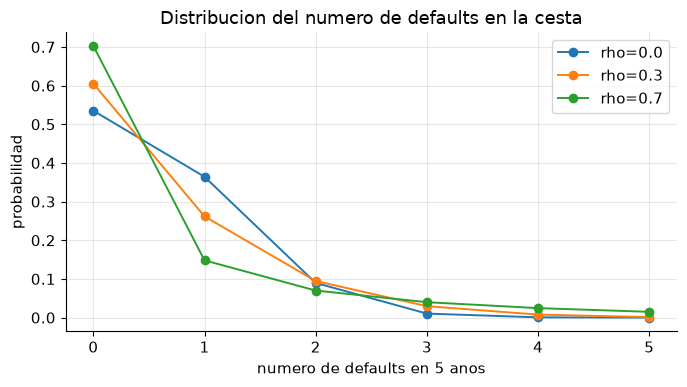

a mayor rho, mas masa en los extremos (0 defaults o todos default) --
mayor correlacion de default vuelve la distribucion mas bimodal.


In [4]:
horizon = 5.0
fig, ax = plt.subplots(figsize=(7, 4))
for rho in [0.0, 0.3, 0.7]:
    tau_rho = simulate_default_times(rho if rho > 0 else 1e-6, n_paths, rng)
    n_defaults = np.sum(tau_rho <= horizon, axis=1)
    counts = np.bincount(n_defaults, minlength=n_names + 1) / n_paths
    ax.plot(range(n_names + 1), counts, "o-", label=f"rho={rho}")
ax.set_xlabel("numero de defaults en 5 anos"); ax.set_ylabel("probabilidad")
ax.set_title("Distribucion del numero de defaults en la cesta")
ax.legend(); fig.tight_layout(); plt.show()

print("a mayor rho, mas masa en los extremos (0 defaults o todos default) --")
print("mayor correlacion de default vuelve la distribucion mas bimodal.")

### Demo 3 — first-to-default: límites $\rho\to0$ y $\rho\to1$

Dos casos límite con respuesta conocida de antemano, útiles para verificar que la cópula está bien implementada. Con $\rho\to0$ (independencia), la probabilidad de que NINGÚN nombre haya defaultado antes de $t$ es simplemente el producto de las supervivencias individuales — no se necesita la cópula para calcularlo, así que sirve de control. Con $\rho\to1$ (comonotonía perfecta), todos los tiempos de default quedan perfectamente ordenados por su hazard: el nombre con mayor $\lambda$ (el más riesgoso) debería ser casi siempre el primero en defaultear.

In [5]:
t_check2 = 3.0

tau_rho0 = simulate_default_times(1e-6, n_paths, rng)
surv_min_sim = np.mean(tau_rho0.min(axis=1) > t_check2)
surv_min_exact = np.prod([survival_i(t_check2, i) for i in range(n_names)])
se_min = np.sqrt(surv_min_exact * (1 - surv_min_exact) / n_paths)
z_rho0 = (surv_min_sim - surv_min_exact) / se_min
print(f"rho~0: P(first-to-default > {t_check2}) sim={surv_min_sim:.4f} "
      f"exacta (prod. de marginales)={surv_min_exact:.4f} z={z_rho0:.2f}")

tau_rho1 = simulate_default_times(0.999999, n_paths, rng)
first_defaulter = np.argmin(tau_rho1, axis=1)
frac_highest_first = np.mean(first_defaulter == np.argmax(lambdas))
print(f"\nrho~1: fraccion de trayectorias donde el nombre de mayor hazard defaultea primero: "
      f"{frac_highest_first:.4f} (comonotonia perfecta esperada, >95%)")

rho~0: P(first-to-default > 3.0) sim=0.6877 exacta (prod. de marginales)=0.6873 z=0.36

rho~1: fraccion de trayectorias donde el nombre de mayor hazard defaultea primero: 1.0000 (comonotonia perfecta esperada, >95%)


## 2. Validación

Tres chequeos: (1) las marginales de la Demo 1 no se distorsionan por la cópula, dentro de 3 SE en cada uno de los 5 nombres; (2) el límite $\rho\to0$ recupera el producto de supervivencias marginales; (3) el límite $\rho\to1$ da comonotonía casi perfecta (el nombre de mayor hazard defaultea primero en más del 95% de las trayectorias).

In [6]:
check1 = np.all(np.abs(marginal_checks) <= 3.0)
print(f"1. marginales no distorsionadas por la copula: max|z|={np.max(np.abs(marginal_checks)):.2f} (<=3? {check1})")

check2 = abs(z_rho0) <= 3.0
print(f"2. limite rho->0 (first-to-default) recupera prod. de supervivencias marginales: "
      f"z={z_rho0:.2f} (<=3? {check2})")

check3 = frac_highest_first > 0.95
print(f"3. limite rho->1 (comonotonia): fraccion={frac_highest_first:.4f} (>0.95? {check3})")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 dentro de tolerancia.")

1. marginales no distorsionadas por la copula: max|z|=0.79 (<=3? True)
2. limite rho->0 (first-to-default) recupera prod. de supervivencias marginales: z=0.36 (<=3? True)
3. limite rho->1 (comonotonia): fraccion=1.0000 (>0.95? True)

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Li, D. (2000). *On Default Correlation: A Copula Function Approach*. Journal of Fixed
  Income, 9(4), 43-54.
- Schönbucher, P., Schubert, D. (2001). *Copula-dependent default risk in intensity
  models*.